# LR Communication Visualizations (CID44971)
Plots generated from `results/CID44971/lr_scores.csv` and `results/CID44971/lr_communication.csv`; figures are saved to `results/CID44971/figures`.


Data columns (assumptions):
- `lr_scores.csv`: spot_i, spot_j, cell_i, cell_j, ligand, receptor, comm_score, in_knn, distance
- `lr_communication.csv`: src_spot_barcode, dst_spot_barcode, source_cell, target_cell, lr_pair, original_lr_score, attention_score
- We derive LR pair stats, spot in/out degree, degree-scaled attention, and optional spatial overlays.


In [1]:
# If dependencies are missing, uncomment the next line (requires internet)
# %pip install pandas matplotlib seaborn scanpy

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")


In [2]:
# Paths
DATA_DIR = Path("results/CID44971")
lr_scores_path = DATA_DIR / "lr_scores.csv"
lr_comm_path = DATA_DIR / "lr_communication.csv"
expr_path = DATA_DIR / "spot_cell_full_expr.csv"  # optional, for ligand/receptor expression
OUTPUT_DIR = DATA_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load data
lr_scores = pd.read_csv(lr_scores_path)
lr_comm = pd.read_csv(lr_comm_path)

# Derive columns
lr_scores["lr_pair"] = lr_scores["ligand"].astype(str) + "_" + lr_scores["receptor"].astype(str)
if "lr_pair" not in lr_comm.columns:
    lr_comm["lr_pair"] = lr_comm["source_cell"].astype(str) + "_" + lr_comm["target_cell"].astype(str)

# Parse ligand/receptor from lr_comm.lr_pair when possible
lr_comm[["lr_ligand", "lr_receptor_combined"]] = lr_comm["lr_pair"].str.split("_", n=1, expand=True)

# Degree-scaled attention (multiply attention by out-degree of the source spot)
src_degree = lr_comm.groupby("src_spot_barcode").size().rename("src_degree")
lr_comm = lr_comm.merge(src_degree, left_on="src_spot_barcode", right_index=True, how="left")
lr_comm["degree_scaled_attention"] = lr_comm["attention_score"] * lr_comm["src_degree"].clip(lower=1)

print(f"lr_scores: {lr_scores.shape}, lr_communication: {lr_comm.shape}")
print("Figures will be saved to", OUTPUT_DIR)


lr_scores: (34600, 10), lr_communication: (68428, 11)
Figures will be saved to results/CID44971/figures


Saved: results/CID44971/figures/celltype_heatmap.png


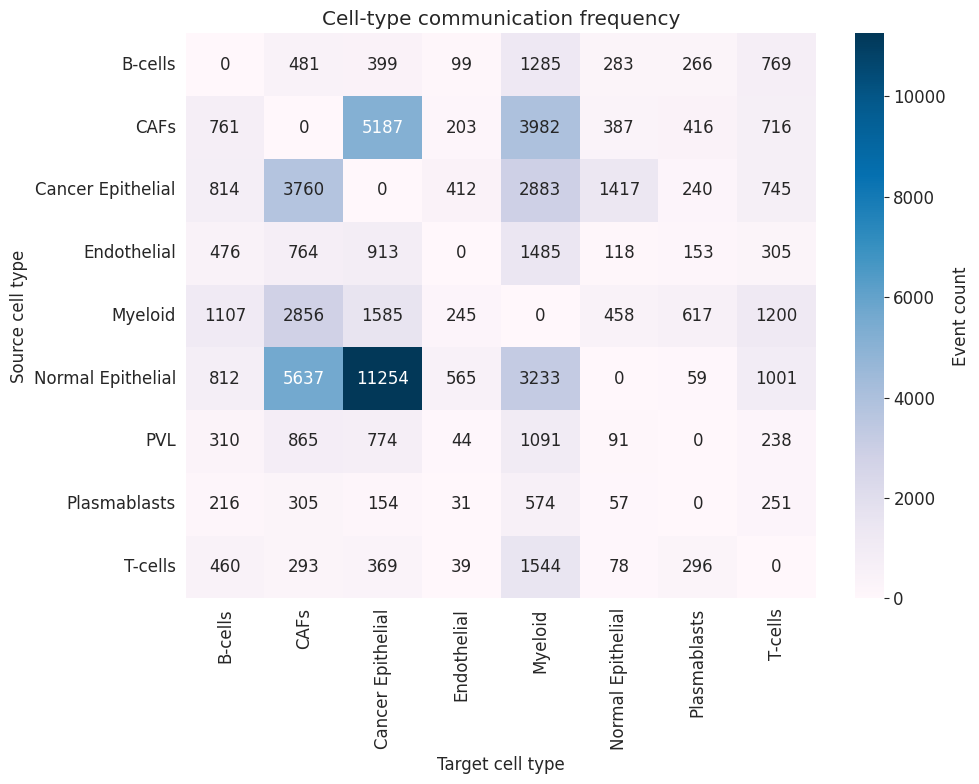

Saved: results/CID44971/figures/celltype_in_out.png


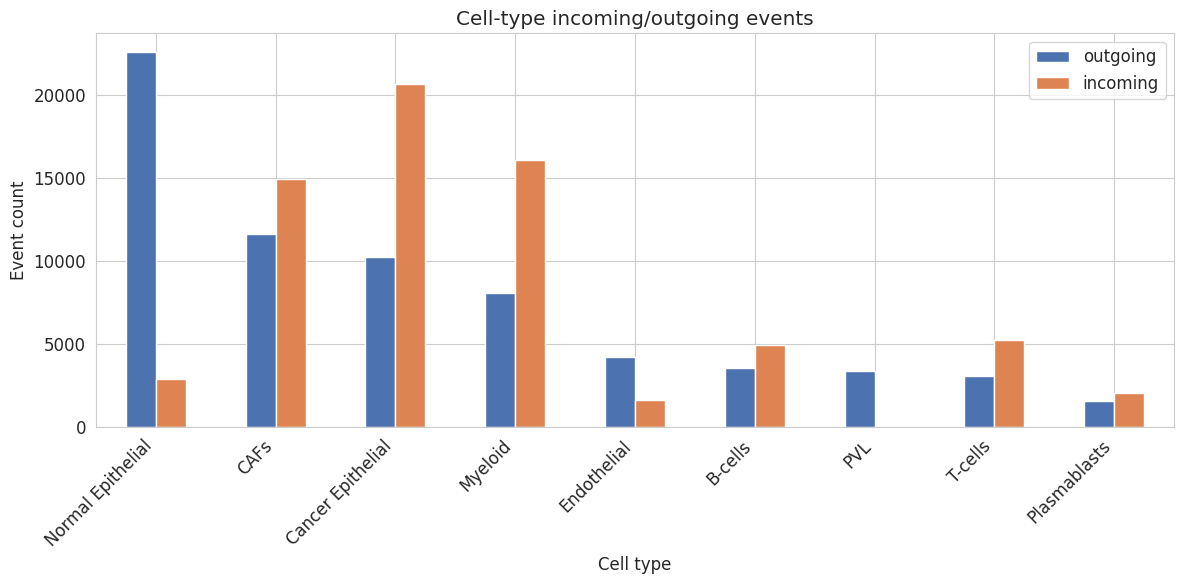

In [3]:
cell_pair_df = (
    lr_comm.groupby(["source_cell", "target_cell"])
    .agg(event_count=("lr_pair", "size"), mean_attention=("attention_score", "mean"))
    .reset_index()
)

cell_matrix = cell_pair_df.pivot(
    index="source_cell", columns="target_cell", values="event_count"
).fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cell_matrix,
    annot=True,
    fmt=".0f",
    cmap="PuBu",
    cbar_kws={"label": "Event count"},
)
plt.title("Cell-type communication frequency")
plt.xlabel("Target cell type")
plt.ylabel("Source cell type")
plt.tight_layout()
fig_path = OUTPUT_DIR / "celltype_heatmap.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

cell_out = lr_comm.groupby("source_cell").size().rename("outgoing")
cell_in = lr_comm.groupby("target_cell").size().rename("incoming")
cell_degree = pd.concat([cell_out, cell_in], axis=1).fillna(0).astype(int)
cell_degree = cell_degree.sort_values("outgoing", ascending=False)

cell_degree.plot(kind="bar", figsize=(12, 6), color=["#4c72b0", "#dd8452"])
plt.title("Cell-type incoming/outgoing events")
plt.xlabel("Cell type")
plt.ylabel("Event count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig_path = OUTPUT_DIR / "celltype_in_out.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()


## LR pairs around top spots
Focus on the busiest spots (top outgoing or incoming) and show which LR pairs dominate those edges.


Saved: results/CID44971/figures/top_pairs_spatial.png


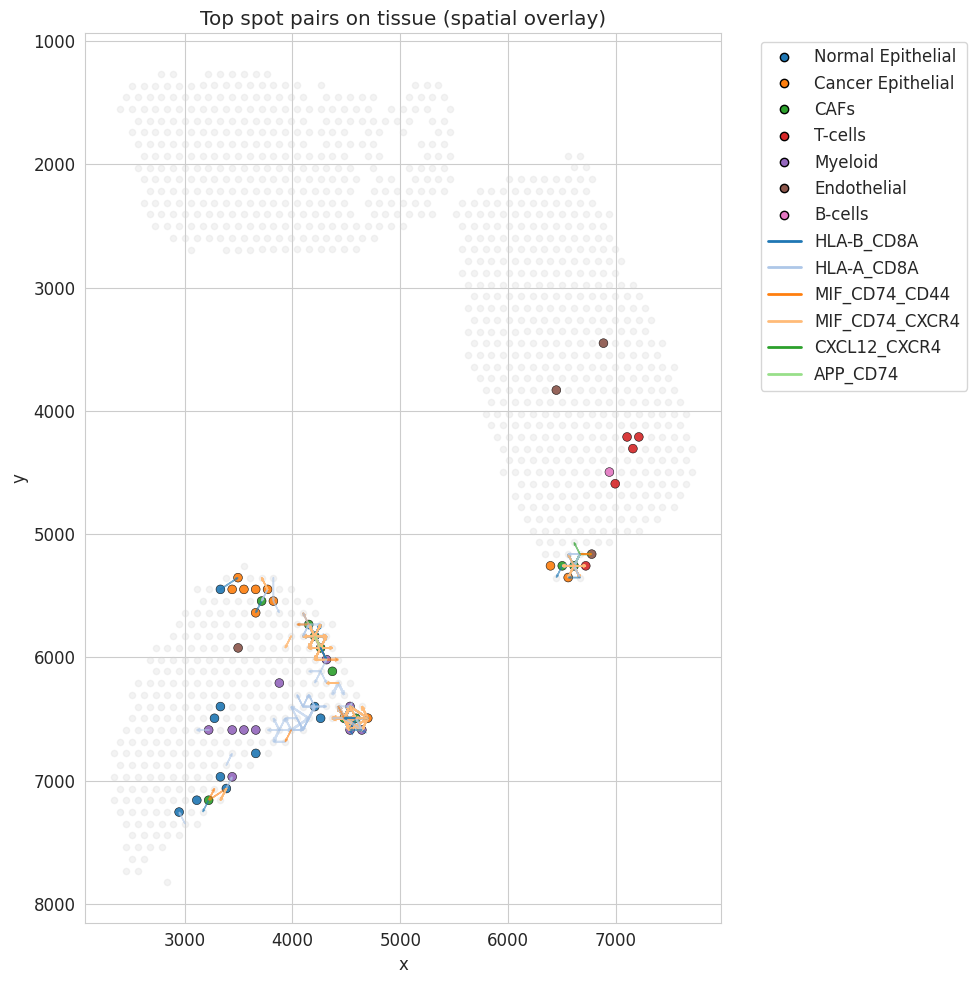

In [4]:
from pathlib import Path

enable_spatial_overlay = True  # set to True when you have the h5ad file and scanpy installed
st_h5ad_path = Path("../ST_Graduation_Project_data/database/Wu/CID44971/CID44971_ST.h5ad")
composition_path = Path("SC_MAP_ST/deconv_results/CID44971/CID44971_cell_composition.csv")

# Build top_pairs (with lr_pair and score) if missing
score_col = 'adjust_score' if 'adjust_score' in lr_comm.columns else ('degree_scaled_attention' if 'degree_scaled_attention' in lr_comm.columns else 'attention_score')
if "top_pairs" not in globals():
    pair_df = (
        lr_comm.groupby(["src_spot_barcode", "dst_spot_barcode", "lr_pair"])
        .agg(
            event_count=("lr_pair", "size"),
            mean_score=(score_col, "mean"),
            max_score=(score_col, "max"),
        )
        .reset_index()
    )
    # Merge with source_cell and target_cell
    pair_df = pair_df.merge(lr_comm[['src_spot_barcode', 'dst_spot_barcode', 'lr_pair', 'source_cell', 'target_cell']].drop_duplicates(), on=['src_spot_barcode', 'dst_spot_barcode', 'lr_pair'])
    
    # Global top edges by mean_score
    top_pairs = pair_df.sort_values("mean_score", ascending=False).head(500)

if enable_spatial_overlay and st_h5ad_path.exists():
    import scanpy as sc
    adata = sc.read_h5ad(st_h5ad_path)
    coords = pd.DataFrame(adata.obsm["spatial"], index=adata.obs_names, columns=["x", "y"])

    # Rank spots by total degree (in + out), top 10 per cell type
    deg_out = lr_comm.groupby("src_spot_barcode").size().rename("out")
    deg_in = lr_comm.groupby("dst_spot_barcode").size().rename("in")
    deg = pd.concat([deg_out, deg_in], axis=1).fillna(0)
    deg["total"] = deg["out"] + deg["in"]
    
    # Dominant cell type per spot from composition (argmax)
    spot_celltype = None
    if composition_path.exists():
        comp_df = pd.read_csv(composition_path, index_col=0)
        spot_celltype = comp_df.idxmax(axis=1)
    
    if spot_celltype is not None:
        top_spots_per_ct = []
        for ct in spot_celltype.unique():
            spots_for_ct = spot_celltype[spot_celltype == ct].index
            deg_ct = deg.loc[deg.index.isin(spots_for_ct)]
            top_for_ct = deg_ct.sort_values("total", ascending=False).head(10)
            top_spots_per_ct.append(top_for_ct)
        top_spots = pd.concat(top_spots_per_ct)
    else:
        top_spots = deg.sort_values("total", ascending=False).head(15)  # fallback to global top 15

    # Prepare arrows for top spot pairs
    arrows = top_pairs.copy()
    arrows["src_x"] = arrows["src_spot_barcode"].map(coords["x"])
    arrows["src_y"] = arrows["src_spot_barcode"].map(coords["y"])
    arrows["dst_x"] = arrows["dst_spot_barcode"].map(coords["x"])
    arrows["dst_y"] = arrows["dst_spot_barcode"].map(coords["y"])
    arrows = arrows.dropna(subset=["src_x", "src_y", "dst_x", "dst_y"])

    # Color map for LR pairs
    lr_unique = arrows["lr_pair"].unique()
    lr_colors = dict(zip(lr_unique, sns.color_palette("tab20", len(lr_unique))))
    arrow_colors = arrows["lr_pair"].map(lr_colors)

    # Line width scaled by mean_score
    if len(arrows) > 0:
        s_min, s_max = arrows["mean_score"].min(), arrows["mean_score"].max()
        lw = 1.0 + (arrows["mean_score"] - s_min) / (s_max - s_min + 1e-6) * 2.0
    else:
        lw = []

    # Color map for top-degree spots by dominant cell type (if available)
    if spot_celltype is not None:
        cell_types = spot_celltype.loc[top_spots.index].fillna("Unknown").unique()
        ct_colors = dict(zip(cell_types, sns.color_palette("tab10", len(cell_types))))
        top_colors = spot_celltype.loc[top_spots.index].map(ct_colors)
    else:
        ct_colors = None
        top_colors = "crimson"

    plt.figure(figsize=(10, 10))
    plt.scatter(coords["x"], coords["y"], s=20, c="lightgray", alpha=0.25, label="All spots")

    plt.scatter(
        coords.loc[top_spots.index, "x"],
        coords.loc[top_spots.index, "y"],
        s=40,
        c=top_colors,
        alpha=0.9,
        label="Top-degree spots",
        edgecolor="k",
        linewidth=0.4,
    )

    for (idx, row), c, lw_i in zip(arrows.iterrows(), arrow_colors, lw):
        plt.arrow(
            row.src_x,
            row.src_y,
            row.dst_x - row.src_x,
            row.dst_y - row.src_y,
            color=c,
            alpha=0.6,
            linewidth=lw_i,
            length_includes_head=True,
            head_width=15,
        )

    lr_handles = [plt.Line2D([0], [0], color=clr, lw=2, label=lp) for lp, clr in lr_colors.items()]
    if ct_colors:
        ct_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=clr, markeredgecolor='k', lw=0,
                                 label=ct) for ct, clr in ct_colors.items()]
    else:
        ct_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson', markeredgecolor='k', lw=0,
                                 label='Top-degree spots')]

    plt.gca().invert_yaxis()
    plt.legend(handles=ct_handles + lr_handles, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title("Top spot pairs on tissue (spatial overlay)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    fig_path = OUTPUT_DIR / "top_pairs_spatial.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()
else:
    print("Spatial overlay disabled (set enable_spatial_overlay=True and provide the h5ad path to enable).")

## Ligand/Receptor expression across cell types (optional)
If `spot_cell_full_expr.csv` exists, this cell summarizes mean expression of top ligands and receptor subunits by cell type (cell type parsed from the suffix of `spot_cell`).


Saved: results/CID44971/figures/ligand_expression_heatmap.png


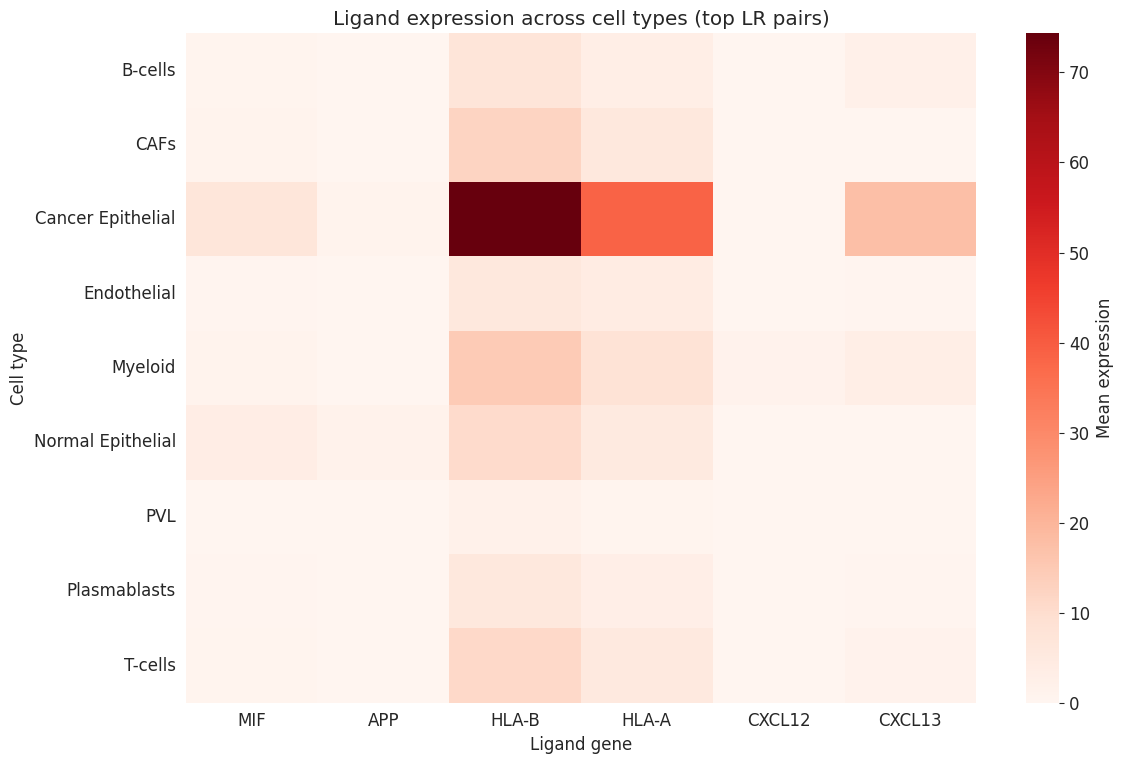

Saved: results/CID44971/figures/receptor_expression_heatmap.png


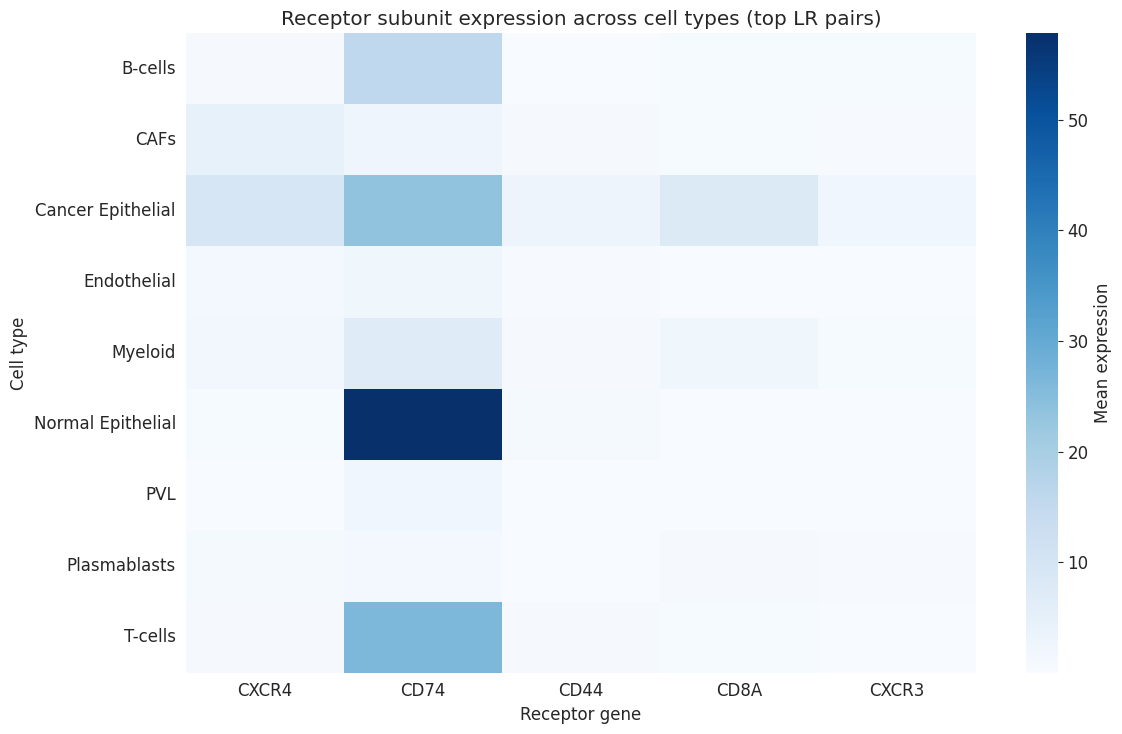

In [6]:
if expr_path.exists():
    expr_df = pd.read_csv(expr_path)
    # Derive cell type from the suffix after the last underscore
    expr_df["cell_type"] = expr_df["spot_cell"].apply(lambda x: str(x).rsplit("_", 1)[-1])

    # Top LR pairs by event count
    top_pairs_for_expr = lr_comm["lr_pair"].value_counts().head(12).index
    ligands = lr_comm[lr_comm["lr_pair"].isin(top_pairs_for_expr)]["lr_ligand"].unique()
    receptor_genes = set()
    for rec_combo in lr_comm[lr_comm["lr_pair"].isin(top_pairs_for_expr)]["lr_receptor_combined"].dropna():
        receptor_genes.update(rec_combo.split("_"))
    ligands = [g for g in ligands if g in expr_df.columns]
    receptor_genes = [g for g in receptor_genes if g in expr_df.columns]

    ligand_expr = expr_df.groupby("cell_type")[ligands].mean().sort_index()
    receptor_expr = expr_df.groupby("cell_type")[receptor_genes].mean().sort_index()

    plt.figure(figsize=(12, 6 + 0.3 * len(ligands)))
    sns.heatmap(ligand_expr, cmap="Reds", cbar_kws={"label": "Mean expression"})
    plt.title("Ligand expression across cell types (top LR pairs)")
    plt.xlabel("Ligand gene")
    plt.ylabel("Cell type")
    plt.tight_layout()
    fig_path = OUTPUT_DIR / "ligand_expression_heatmap.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()

    plt.figure(figsize=(12, 6 + 0.3 * len(receptor_genes)))
    sns.heatmap(receptor_expr, cmap="Blues", cbar_kws={"label": "Mean expression"})
    plt.title("Receptor subunit expression across cell types (top LR pairs)")
    plt.xlabel("Receptor gene")
    plt.ylabel("Cell type")
    plt.tight_layout()
    fig_path = OUTPUT_DIR / "receptor_expression_heatmap.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    print("Saved:", fig_path)
    plt.show()
else:
    print("Expression file not found; skipping ligand/receptor expression heatmaps.")


## Top 5 ligands/receptors spatial expression
Plot the top-5 ligands and receptors (by event count) on the tissue slice. Receptor combos are averaged across available subunits.


In [7]:
import numpy as np
enable_spatial_expr = True
spatial_expr_h5ad = st_h5ad_path  # reuse path above

if enable_spatial_expr and spatial_expr_h5ad.exists():
    if "lr_ligand" not in lr_comm.columns:
        lr_comm[["lr_ligand", "lr_receptor_combined"]] = lr_comm["lr_pair"].str.split("_", n=1, expand=True)

    top_ligands = lr_comm["lr_ligand"].value_counts().head(5).index.tolist()
    top_receptors = lr_comm["lr_receptor_combined"].value_counts().head(5).index.tolist()

    if "adata" not in locals():
        import scanpy as sc
        adata = sc.read_h5ad(spatial_expr_h5ad)
    coords = np.array(adata.obsm["spatial"])

    def fetch_expr(gene):
        if gene not in adata.var_names:
            return None
        expr = adata[:, gene].X
        if hasattr(expr, "toarray"):
            expr = expr.toarray()
        return np.ravel(expr)

    def plot_gene(gene, expr_vals, kind):
        if expr_vals is None:
            print(f"[{kind}] skip {gene}: not found")
            return
        plt.figure(figsize=(6, 5))
        plt.scatter(coords[:, 0], coords[:, 1], c=expr_vals, cmap="viridis", s=10, linewidth=0)
        plt.colorbar(label="expression")
        plt.title(f"{kind}: {gene}")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        out_path = OUTPUT_DIR / f"spatial_{kind}_{gene}.png"
        plt.savefig(out_path, dpi=200)
        plt.close()
        print("Saved", out_path)

    for lg in top_ligands:
        plot_gene(lg, fetch_expr(lg), "ligand")

    for rc in top_receptors:
        parts = [p for p in str(rc).split("_") if p]
        expr_list = []
        for p in parts:
            val = fetch_expr(p)
            if val is not None:
                expr_list.append(val)
        avg_expr = np.mean(expr_list, axis=0) if expr_list else None
        plot_gene(rc.replace("_", "+"), avg_expr, "receptor")
else:
    print("Spatial h5ad not found or disabled; skip spatial expression maps.")


Saved results/CID44971/figures/spatial_ligand_MIF.png
Saved results/CID44971/figures/spatial_ligand_HLA-B.png
Saved results/CID44971/figures/spatial_ligand_HLA-A.png
Saved results/CID44971/figures/spatial_ligand_APP.png
Saved results/CID44971/figures/spatial_ligand_CXCL12.png
Saved results/CID44971/figures/spatial_receptor_CD74+CXCR4.png
Saved results/CID44971/figures/spatial_receptor_CD8A.png
Saved results/CID44971/figures/spatial_receptor_CD74.png
Saved results/CID44971/figures/spatial_receptor_CD74+CD44.png
Saved results/CID44971/figures/spatial_receptor_CXCR4.png
